# 02. Boosting 모델 학습

학습 기간 유연 설정 (PERIOD_MODE 사용)

In [1]:
import pandas as pd, numpy as np, warnings
import xgboost as xgb, lightgbm as lgb, optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostRegressor,CatBoostClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
import optuna
from sklearn.metrics import r2_score
optuna.logging.set_verbosity(optuna.logging.WARNING)  # 로그 최소화

N_TRIALS = 100
import sklearn.preprocessing
import pickle

smote = SMOTE(random_state=42)
warnings.filterwarnings("ignore")
# ════════════════════════════════════════════════
# ✏️  학습 기간 설정 (세 가지 방식 중 하나만 선택)
# ════════════════════════════════════════════════

PERIOD_MODE = "from"       # "range"   : 특정 구간만 학습
                            # "exclude" : 특정 구간을 제외하고 학습
                            # "from"    : 특정 연도 이후만 학습 (기존 방식)

PERIOD_START = 2020         # 구간 시작 연도 (range / exclude 공통)
PERIOD_END   = 2021       # 구간 종료 연도 (range / exclude 공통)
MIN_YEAR     = 2016         # "from" 모드일 때만 사용
# ════════════════════════════════════════════════

# 설정
FEATURE_VERSION = "v3"
SPLIT_STRATEGY = "year"
TARGET_TYPE = "regression" # regression , classification
TEST_SIZE = 0.2
RANDOM_STATE = 42
ENABLE_TUNING = True
N_TRIALS = 50
CV_FOLDS = 5
print(f"✅ 설정 완료: {FEATURE_VERSION}, PERIOD_MODE = {PERIOD_MODE}, PERIOD_START = {PERIOD_START}, PERIOD_END = {PERIOD_END} ,MIN_YEAR = {MIN_YEAR}")

c:\Users\playdata2\SK_AI_CAMP_Project2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 설정 완료: v3, PERIOD_MODE = from, PERIOD_START = 2020, PERIOD_END = 2021 ,MIN_YEAR = 2016


In [2]:
# 데이터 로드
df = pd.read_csv(f"data/processed/feature_table_{FEATURE_VERSION}.csv", encoding="utf-8-sig")

# open_date를 datetime으로 변환 (결측치 처리)
df["open_date"] = pd.to_datetime(df["open_date"], errors="coerce")

# open_year 추출
df["open_year"] = df["open_date"].dt.year.astype("Int64")  # NaT 허용하는 정수형

# 코로나 기간 제외
# df = (
#     df[~df['open_year'].isin([2020, 2021])]
#     .reset_index(drop=True)
# )

# 감독-배우 조합 과거 평균
# df['director_actor_combo_count'] = df.groupby(['director', 'lead_actor'])['movie_id'].transform('count')
# 검증
print(f"✅ {FEATURE_VERSION} 로드: {df.shape[0]:,}편")
print(f"   개봉 년도: {int(df['open_year'].min())}~{int(df['open_year'].max())}")
print(f"   open_date 결측치: {df['open_date'].isna().sum()}건")

✅ v3 로드: 2,489편
   개봉 년도: 2016~2025
   open_date 결측치: 0건


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2489 entries, 0 to 2488
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   movie_id                 2489 non-null   str           
 1   title                    2489 non-null   str           
 2   genre                    2489 non-null   str           
 3   nation                   2489 non-null   str           
 4   open_date                2489 non-null   datetime64[us]
 5   runtime                  2489 non-null   int64         
 6   total_audience           2489 non-null   int64         
 7   total_sales              2489 non-null   int64         
 8   director_avg_audi        2489 non-null   float64       
 9   director_movie_count     2489 non-null   int64         
 10  lead_actor_avg_audi      2489 non-null   float64       
 11  lead_actor_movie_count   2489 non-null   int64         
 12  distributor_avg_audi     2489 non-null   floa

In [4]:
# PERIOD_MODE에 따라 학습 데이터 필터링

if PERIOD_MODE == "range":
    # 특정 구간만 학습 (예: 2012~2020)
    mask = (df["open_year"] >= PERIOD_START) & (df["open_year"] <= PERIOD_END)
    desc = f"{PERIOD_START}~{PERIOD_END}년"

elif PERIOD_MODE == "exclude":
    # 특정 구간 제외 (예: 코로나 2020~2021 제외)
    mask = ~((df["open_year"] >= PERIOD_START) & (df["open_year"] <= PERIOD_END))
    desc = f"{PERIOD_START}~{PERIOD_END}년 제외"

elif PERIOD_MODE == "from":
    # 특정 연도 이후만 (기존 방식)
    mask = df["open_year"] >= MIN_YEAR
    desc = f"{MIN_YEAR}년 이후"


print(f"📅 학습 기간 모드  : {PERIOD_MODE} ({desc})")


📅 학습 기간 모드  : from (2016년 이후)


In [5]:
# hit_class 재구성,(기본 0,1,2,3[0~100,100~300,300~500,500~])
# REMAP = {0: 0, 1: 1, 2: 1, 3: 1}  # 100만 미만=0, 이상=1
# df['hit_class'] = df['hit_class'].map(REMAP).astype('Int64')

# print(df['hit_class'].value_counts().sort_index())
# 예상: 0 → 2121편 / 1 → 333편  (약 6.4:1)

### v3 제안해볼만한 feature 추가 테스트 !!

In [6]:
# # 성수기에 검색량까지 높으면 시너지
# df['peak_x_trend'] = df['is_peak_season'] * df['trend_pre7_avg']

# # 배급사 + 제작사 + 감독 + 배우 평균을 가중 합산
# df['brand_power_score'] = (
#     df['distributor_avg_audi'] * 0.4 +
#     df['producer_avg_audi']    * 0.2 +
#     df['director_avg_audi']    * 0.2 +
#     df['lead_actor_avg_audi']  * 0.2
# )

# # → 근사치: 두 avg가 비슷한 수준이면 시너지 있다고 판단
# df['star_director_synergy'] = (
#     df['director_avg_audi'] * df['lead_actor_avg_audi']
# ).apply(np.log1p)

# # 같은 주 개봉작 수 대비 시장 평균 관객 → 경쟁이 치열한데 시장도 작으면 불리
# df['competition_pressure'] = (
#     df['same_week_releases'] / (df['market_avg_audi_7d'] + 1)
# ).apply(np.log1p)

# # 검색량 최고점 대비 평균 비율 → 검색이 특정일 폭발적인지 vs 꾸준한지
# df['trend_peak_ratio'] = (
#     df['trend_pre7_max'] / (df['trend_pre7_avg'] + 1e-6)
# ).clip(upper=10)  # 이상치 제한

# # 검색량은 높은데 감독/배우 실적이 낮은 경우 → 기대작이지만 검증 안 된 경우
# df['hype_vs_track'] = (
#     df['trend_pre7_avg'] / (df['director_avg_audi'] + df['lead_actor_avg_audi'] + 1)
# ).apply(np.log1p)

# # 편수 많고 평균 높으면 → 검증된 배급사
# df['distributor_reliability'] = (
#     df['distributor_avg_audi'] * np.log1p(df['distributor_movie_count'])
# )

In [7]:
# drop_cols = [
#     # 상관관계 0에 수렴 → 노이즈
#     'open_month',        # open_day_of_week, is_summer/winter로 커버됨
#     'trend_peak_ratio',  # trend_pre7_avg, trend_pre7_max으로 커버됨
#     'distributor_reliability',  # distributor_avg_audi와 거의 동일 정보
    
#     # is_summer/is_winter/is_peak_season 중복
#     'is_summer',         # is_peak_season에 흡수됨
#     'is_winter'        # is_peak_season에 흡수됨  # ✅ 쉼표 추가
# ]

# drop_cols = [c for c in drop_cols if c in df.columns]
# df = df.drop(columns=drop_cols)

# print(f'제거된 피처: {drop_cols}')
# print(f'남은 피처 수: {len(df.columns)}')


In [8]:
# # Int64 (nullable) → int64로 통일 (XGB/LGBM에서 간헐적 오류 방지)
# df['open_year'] = df['open_year'].astype('int64')

# # avg_audi 계열은 이미 log 변환됐는지 확인 필요
# log_cols = [
#     'director_avg_audi',
#     'lead_actor_avg_audi', 
#     'distributor_avg_audi',
#     'producer_avg_audi',
#     'market_avg_audi_7d',
#     'genre_avg_audi',
#     'cast_max_star_power',
# ]

# for col in log_cols:
#     if df[col].max() > 1000:  # 아직 log 변환 안 된 경우만
#         df[col] = np.log1p(df[col])
#         print(f'log1p 적용: {col}')

# # competition_pressure, hype_vs_track은 극단값 있을 수 있음
# clip_cols = ['competition_pressure', 'hype_vs_track', 'trend_peak_ratio']

# for col in clip_cols:
#     if col in df.columns:
#         upper = df[col].quantile(0.99)
#         df[col] = df[col].clip(upper=upper)
#         print(f'클리핑 적용: {col} (상한: {upper:.4f})')



In [9]:
df_train = df[mask].copy()
target_col = "log_audience" if TARGET_TYPE == "regression" else "hit_class"
y = df_train[target_col].copy()

exclude_cols = ['movie_id', 'title', 'genre', 'nation', 'open_date', 
'total_audience', 'total_sales', 'log_audience',
 # v2 스펙 삭제 대상 피처 (다중공선성 방지)
    'open_month', 'director_movie_count', 'lead_actor_movie_count', 
    'distributor_movie_count', 'producer_movie_count', 'cast_max_star_power','trend_pre30_avg']

feature_cols = [c for c in df_train.columns if c not in exclude_cols]
X = df_train[feature_cols].copy()

# 혹시 남아있는 object 컬럼 강제 처리
obj_cols = X.select_dtypes(include=['object']).columns.tolist()
if obj_cols:
    print(f'⚠️ object 컬럼 발견 → LabelEncoder 적용: {obj_cols}')
    for col in obj_cols:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
numeric_cols = [
    col for col in df.columns
    if col not in exclude_cols
    and df[col].dtype != 'object'  # 이 줄 있는지 확인
]

print(f"피처: {len(feature_cols)}, 샘플: {len(y):,}")
# object 타입 컬럼 확인
print(X.select_dtypes(include=['object']).columns.tolist())

피처: 30, 샘플: 2,489
[]


In [10]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 2489 entries, 0 to 2488
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   runtime                2489 non-null   int64  
 1   director_avg_audi      2489 non-null   float64
 2   lead_actor_avg_audi    2489 non-null   float64
 3   distributor_avg_audi   2489 non-null   float64
 4   producer_avg_audi      2489 non-null   float64
 5   trend_pre7_avg         2489 non-null   float64
 6   trend_pre7_max         2489 non-null   float64
 7   trend_growth_rate      2489 non-null   float64
 8   relative_search_share  2489 non-null   float64
 9   market_avg_audi_7d     2489 non-null   float64
 10  ticket_price_pre30     2489 non-null   float64
 11  open_day_of_week       2489 non-null   int64  
 12  is_summer              2489 non-null   int64  
 13  is_winter              2489 non-null   int64  
 14  is_peak_season         2489 non-null   int64  
 15  is_covid_period

In [11]:
# Train/Test 분할
if SPLIT_STRATEGY == "year":
    sorted_idx = df_train.sort_values("open_year").index
    split_idx = int(len(sorted_idx) * (1 - TEST_SIZE))
    train_idx, test_idx = sorted_idx[:split_idx], sorted_idx[split_idx:]
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

Train: 1,991, Test: 498


In [12]:
# 분류 모드일 때만 클래스 비율 계산
if TARGET_TYPE == "classification":
    counter = Counter(y_train)
    neg, pos = counter[0], counter[1]
    scale = neg / pos
    print(f'class 0 (일반): {neg}, class 1 (흥행): {pos}')
    print(f'scale_pos_weight: {scale:.2f}')
else:
    print('ℹ️  regression 모드 → 클래스 비율 계산 건너뜀')


ℹ️  regression 모드 → 클래스 비율 계산 건너뜀


In [13]:
# smote 적용
smote = SMOTE(random_state=42)

In [14]:
# XGBoost
if TARGET_TYPE == "regression":
    xgb_model = xgb.XGBRegressor(
        max_depth=6,
        learning_rate=0.05,
        n_estimators=1000,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbosity=0
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    y_pred = xgb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ XGBoost: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    # ✅ 이진분류 (binary:logistic) - multi:softmax 제거
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    xgb_model = xgb.XGBClassifier(
        objective="binary:logistic",
        max_depth=6,
        learning_rate=0.05,
        n_estimators=1000,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        verbosity=0
    )
    xgb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = xgb_model.predict(X_test)
    y_prob = xgb_model.predict_proba(X_test)[:, 1]  # ✅ xgb_model로 통일
    threshold = 0.3
    y_pred_adj = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ XGBoost: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred_adj)
    print(cm)
    print(classification_report(y_test, y_pred_adj))


✅ XGBoost: RMSE=1.5356, R²=0.4322


In [15]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': 42
    }
    if TARGET_TYPE == "regression":
        model = xgb.XGBRegressor(**params, verbosity=0)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        return r2_score(y_test, model.predict(X_test))
    else:
        model = xgb.XGBClassifier(**params, objective="binary:logistic",
                                   scale_pos_weight=scale, eval_metric='logloss', verbosity=0)
        model.fit(X_train_resampled, y_train_resampled)
        return f1_score(y_test, model.predict(X_test))

if ENABLE_TUNING:
    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)
    print('XGB 최적값:', study_xgb.best_value)
    print('XGB 최적 파라미터:', study_xgb.best_params)


XGB 최적값: 0.5396805413649011
XGB 최적 파라미터: {'n_estimators': 863, 'max_depth': 3, 'learning_rate': 0.005934921506705023, 'subsample': 0.6839996494742674, 'colsample_bytree': 0.5002998622747432, 'min_child_weight': 1, 'reg_alpha': 0.37388378953696294, 'reg_lambda': 2.3814074258429286e-06}


In [16]:
# LightGBM
if TARGET_TYPE == "regression":
    lgb_model = lgb.LGBMRegressor(
        max_depth=6,
        learning_rate=0.05,
        n_estimators=1000,  # ✅ 100 → 1000
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1
    )
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    y_pred = lgb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ LightGBM: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    lgb_model = lgb.LGBMClassifier(
        max_depth=6,
        learning_rate=0.05,
        n_estimators=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        verbose=-1
    )
    lgb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = lgb_model.predict(X_test)
    y_prob = lgb_model.predict_proba(X_test)[:, 1]  # ✅ lgb_model로 수정
    threshold = 0.3
    y_pred_adj = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ LightGBM: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred_adj)
    print(cm)
    print(classification_report(y_test, y_pred_adj))


✅ LightGBM: RMSE=1.4186, R²=0.5154


In [17]:
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'random_state': 42,
        'verbose': -1
    }
    if TARGET_TYPE == "regression":
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        return r2_score(y_test, model.predict(X_test))
    else:
        model = lgb.LGBMClassifier(**params, class_weight='balanced')
        model.fit(X_train_resampled, y_train_resampled)
        return f1_score(y_test, model.predict(X_test))

if ENABLE_TUNING:
    study_lgb = optuna.create_study(direction='maximize')
    study_lgb.optimize(objective_lgb, n_trials=N_TRIALS)
    print('LGB 최적값:', study_lgb.best_value)
    print('LGB 최적 파라미터:', study_lgb.best_params)


LGB 최적값: 0.5524012818970885
LGB 최적 파라미터: {'n_estimators': 797, 'max_depth': 3, 'learning_rate': 0.07547574825052426, 'subsample': 0.6275910164022495, 'colsample_bytree': 0.575048451387538, 'min_child_samples': 83, 'reg_alpha': 0.03538800255930426, 'reg_lambda': 3.276394057169492, 'num_leaves': 255}


In [18]:
# CatBoost
if TARGET_TYPE == "regression":
    cb_model = CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=6,
        loss_function='RMSE',
        eval_metric='R2',
        random_seed=RANDOM_STATE,
        verbose=100
    )
    cb_model.fit(X_train, y_train, eval_set=(X_test, y_test))
    y_pred = cb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ CatBoost: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    cb_model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='F1',
        depth=6,
        learning_rate=0.03,
        iterations=2000,
        l2_leaf_reg=5,
        random_seed=RANDOM_STATE,
        verbose=0,
        class_weights=[1, scale]
    )
    cb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = cb_model.predict(X_test)
    y_prob = cb_model.predict_proba(X_test)[:, 1]  # ✅ cb_model로 수정
    threshold = 0.3
    y_pred_adj = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ CatBoost: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred_adj)
    print(cm)
    print(classification_report(y_test, y_pred_adj))


0:	learn: 0.0312757	test: 0.0233871	best: 0.0233871 (0)	total: 122ms	remaining: 4m 3s
100:	learn: 0.7290265	test: 0.5302596	best: 0.5302596 (100)	total: 338ms	remaining: 6.35s
200:	learn: 0.7853872	test: 0.5322530	best: 0.5356789 (162)	total: 557ms	remaining: 4.98s
300:	learn: 0.8138522	test: 0.5339753	best: 0.5359493 (288)	total: 764ms	remaining: 4.31s
400:	learn: 0.8360081	test: 0.5301548	best: 0.5359493 (288)	total: 968ms	remaining: 3.86s
500:	learn: 0.8547131	test: 0.5282510	best: 0.5359493 (288)	total: 1.22s	remaining: 3.65s
600:	learn: 0.8720616	test: 0.5273297	best: 0.5359493 (288)	total: 1.44s	remaining: 3.35s
700:	learn: 0.8868860	test: 0.5231656	best: 0.5359493 (288)	total: 1.66s	remaining: 3.07s
800:	learn: 0.8986961	test: 0.5188768	best: 0.5359493 (288)	total: 1.86s	remaining: 2.79s
900:	learn: 0.9087941	test: 0.5155737	best: 0.5359493 (288)	total: 2.07s	remaining: 2.53s
1000:	learn: 0.9177068	test: 0.5107408	best: 0.5359493 (288)	total: 2.28s	remaining: 2.27s
1100:	learn: 

In [19]:
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 2000),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'random_seed': 42,
        'verbose': 0
    }
    if TARGET_TYPE == "regression":
        model = CatBoostRegressor(**params)
        model.fit(X_train, y_train, eval_set=(X_test, y_test),
                  early_stopping_rounds=50, verbose=False)
        return r2_score(y_test, model.predict(X_test))
    else:
        model = CatBoostClassifier(**params, loss_function='Logloss',
                                   class_weights=[1, scale])
        model.fit(X_train_resampled, y_train_resampled)
        return f1_score(y_test, model.predict(X_test))

if ENABLE_TUNING:
    study_cat = optuna.create_study(direction='maximize')
    study_cat.optimize(objective_cat, n_trials=N_TRIALS)
    print('CAT 최적값:', study_cat.best_value)
    print('CAT 최적 파라미터:', study_cat.best_params)


CAT 최적값: 0.5699019904219325
CAT 최적 파라미터: {'iterations': 365, 'depth': 4, 'learning_rate': 0.05468505449600897, 'l2_leaf_reg': 3.21561835915569e-08, 'subsample': 0.7318363784167181, 'colsample_bylevel': 0.5148731778974988, 'min_data_in_leaf': 50}


In [20]:
# 잔차 분석 - 어떤 영화를 틀리고 있는지
y_pred = xgb_model.predict(X_test)
residuals = y_test - y_pred

# 많이 틀리는 영화 확인
error_df = pd.DataFrame({
    'title': df.loc[X_test.index, 'title'],
    'actual': y_test,
    'predicted': y_pred,
    'error': residuals.abs()
}).sort_values('error', ascending=False)

print(error_df.head(20))

                       title     actual  predicted     error
2423          극장판 체인소 맨: 레제편  15.047054   8.472250  6.574804
2370          쥬라기 월드: 새로운 시작  14.601288   8.530420  6.070868
2265      캡틴 아메리카: 브레이브 뉴 월드  14.317896   9.307977  5.009919
2190              베놈: 라스트 댄스  14.380803   9.375404  5.005399
2401        극장판 귀멸의 칼날: 무한성편  15.549735  10.760188  4.789547
2027                    건국전쟁  13.972494   9.206038  4.766455
2465                위키드: 포 굿  13.779584   9.089250  4.690334
2470  극장판 주술회전: 시부야사변 X 사멸회유  12.787011   8.345202  4.441808
2376          명탐정 코난: 척안의 잔상  13.518498   9.083524  4.434975
2440         극장판 주술회전: 회옥·옥절  12.291792   7.873127  4.418665
2330                   썬더볼츠＊  13.729025   9.443814  4.285211
2240             더 폴: 디렉터스 컷  11.949282   7.885550  4.063732
2385          판타스틱 4: 새로운 출발  13.249544   9.238184  4.011360
2235  극장판 짱구는 못말려: 우리들의 공룡일기  13.575693   9.579336  3.996356
2407             컨저링: 마지막 의식  12.925930   9.021677  3.904253
2479               아바타: 

# Feature Correlation / Importance 분석 셀

## 1. log_audience와 상관계수 높은 feature 출력

In [21]:
# Boosting 학습 파일에 추가할 Feature Correlation / Importance 분석 셀
import matplotlib.pyplot as plt
import seaborn as sns

# 분석 대상 컬럼
exclude_cols = [
    'movie_id', 'title', 'genre', 'nation',  # ✅ nation 추가
    'open_date', 'total_audience', 'hit_class'
]

numeric_cols = [
    col for col in df.columns
    if col not in exclude_cols
    and df[col].dtype != 'object'  # ✅ object 타입 전체 방어
]

# 상관계수 계산
corr_series = (
    df[numeric_cols]
    .corr()['log_audience']
    .drop('log_audience', errors='ignore')
    .sort_values(key=abs, ascending=False)
)

print('=' * 60)
print(f'{FEATURE_VERSION} log_audience 와의 상관계수 TOP 15')
print('=' * 60)
print(corr_series.head(15))


v3 log_audience 와의 상관계수 TOP 15
total_sales               0.620300
relative_search_share     0.537763
distributor_avg_audi      0.478880
trend_pre30_avg           0.475634
trend_pre7_avg            0.468890
lead_actor_movie_count    0.411489
trend_pre7_max            0.349554
is_new_director          -0.313931
genre_avg_audi            0.296906
is_new_lead              -0.294841
is_new_producer          -0.290251
runtime                   0.286210
market_avg_audi_7d        0.281451
is_covid_period          -0.278935
director_avg_audi         0.269868
Name: log_audience, dtype: float64


## 2. 상관계수 시각화

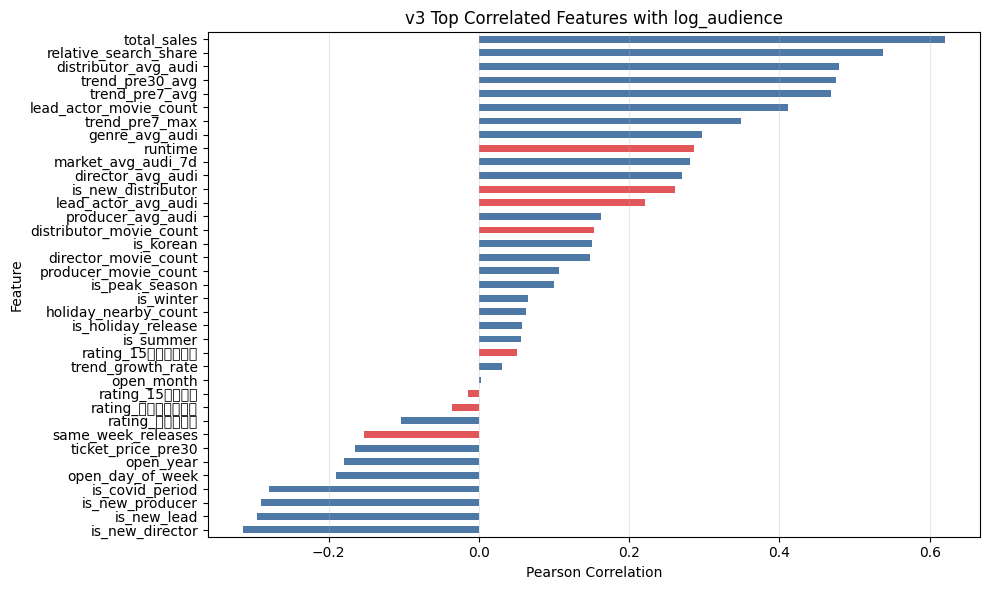

In [22]:
plt.figure(figsize=(10, 6))

colors = [
    '#4e79a7' if v > 0 else '#e15759'
    for v in corr_series.head(15).values
]

corr_series.sort_values().plot(
    kind='barh',
    color=colors
)

plt.title(f'{FEATURE_VERSION} Top Correlated Features with log_audience')
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 전체 Feature Heatmap

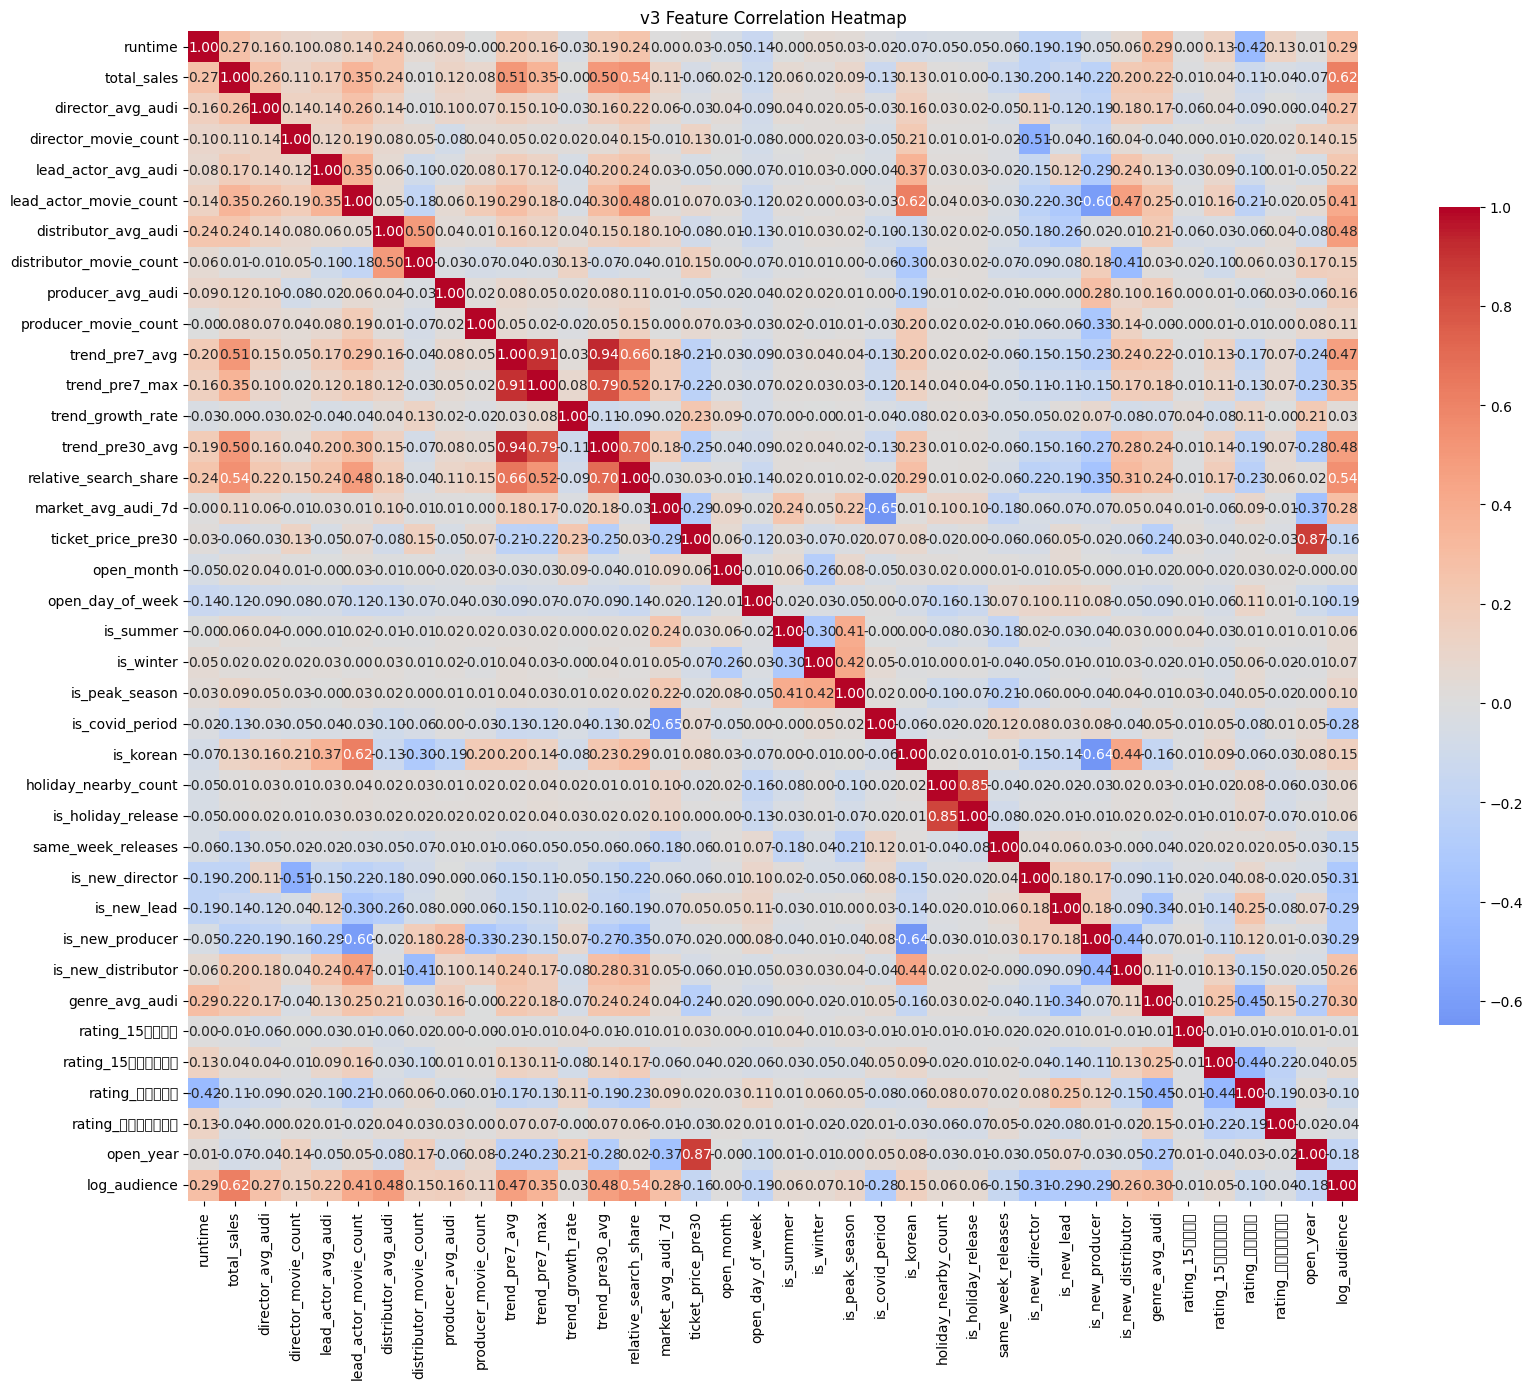

In [23]:
# =====================================================
# Feature Heatmap
# =====================================================

heatmap_cols = [
    col for col in numeric_cols
    if col != 'log_audience'
]

corr_matrix = df[
    heatmap_cols + ['log_audience']
].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    cbar_kws={'shrink': 0.7}
)

plt.title(f'{FEATURE_VERSION} Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. CatBoost Feature Importance 시각화

In [24]:
# =====================================================
# CatBoost Feature Importance
# =====================================================

feature_names = X.columns

cat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': cb_model.feature_importances_
})

cat_importance = (
    cat_importance
    .sort_values('importance', ascending=False)
)
cat_importance=cat_importance.reset_index()
print('=' * 60)
print(f'{FEATURE_VERSION} CatBoost Feature Importance TOP 20')
print('=' * 60)

display(cat_importance.head(20))

v3 CatBoost Feature Importance TOP 20


,index,feature,importance
0,6,trend_pre7_max,17.023314
1,3,distributor_avg_audi,14.550411
2,5,trend_pre7_avg,14.351407
3,24,genre_avg_audi,5.973696
4,8,relative_search_share,5.652703
5,10,ticket_price_pre30,4.388669
6,29,open_year,4.111916
7,9,market_avg_audi_7d,3.944623
8,1,director_avg_audi,3.507598
9,0,runtime,3.385223


## 5. Feature Importance 시각화

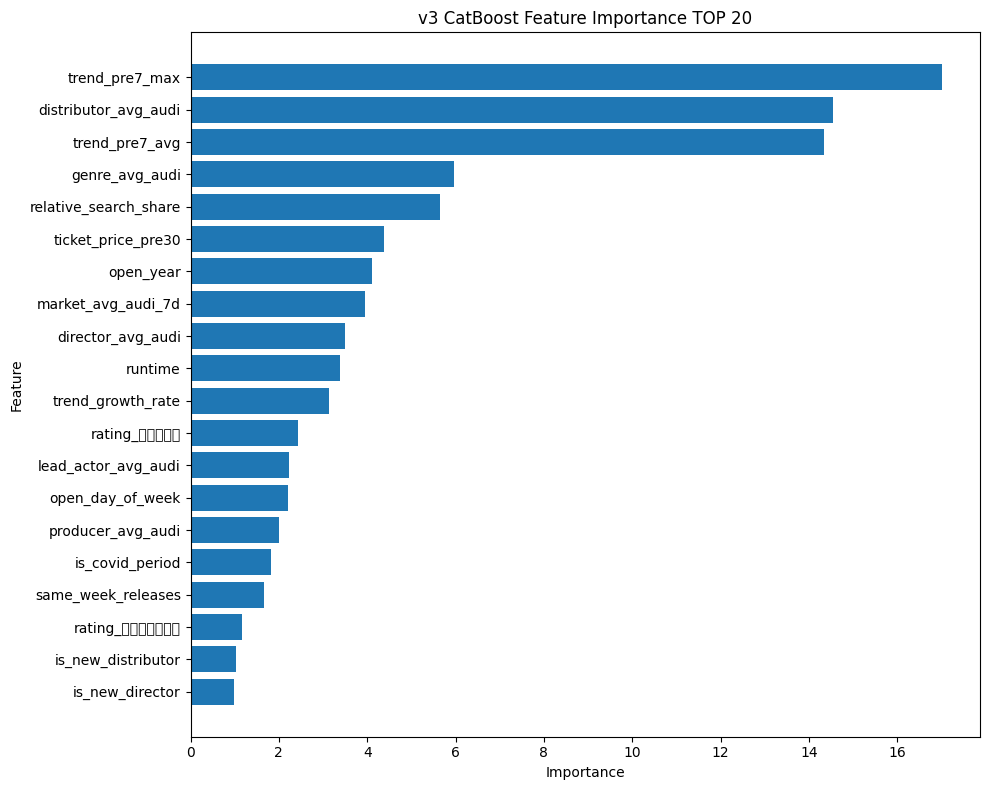

In [25]:
plt.figure(figsize=(10, 8))

plot_df = cat_importance.head(20).sort_values('importance')

plt.barh(
    plot_df['feature'],
    plot_df['importance']
)

plt.title(f'{FEATURE_VERSION} CatBoost Feature Importance TOP 20')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [26]:
# 모드별 파일명 자동 생성
period_tag = {
    "range"  : f"{PERIOD_START}_{PERIOD_END}",
    "exclude": f"ex{PERIOD_START}_{PERIOD_END}",
    "from"   : f"from{MIN_YEAR}",
}[PERIOD_MODE]

model_prefix = f"{FEATURE_VERSION}_{period_tag}"

with open(f"models/{model_prefix}_xgboost.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
with open(f"models/{model_prefix}_lightgbm.pkl", "wb") as f:
    pickle.dump(lgb_model, f)
with open(f"models/{model_prefix}_catboost.pkl", "wb") as f:
    pickle.dump(cb_model, f)

print(f"✅ 모델 저장 완료: models/{model_prefix}_*.pkl")

✅ 모델 저장 완료: models/v3_from2016_*.pkl


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2489 entries, 0 to 2488
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   movie_id                 2489 non-null   str           
 1   title                    2489 non-null   str           
 2   genre                    2489 non-null   str           
 3   nation                   2489 non-null   str           
 4   open_date                2489 non-null   datetime64[us]
 5   runtime                  2489 non-null   int64         
 6   total_audience           2489 non-null   int64         
 7   total_sales              2489 non-null   int64         
 8   director_avg_audi        2489 non-null   float64       
 9   director_movie_count     2489 non-null   int64         
 10  lead_actor_avg_audi      2489 non-null   float64       
 11  lead_actor_movie_count   2489 non-null   int64         
 12  distributor_avg_audi     2489 non-null   floa